# AIHub OCR 데이터셋 검증 노트북

이 노트북은 `S:\OCR_Data` 아래의 "_KE_" 폴더를 스캔하고,
이미지-라벨 매칭, 통계, 샘플 시각화를 수행합니다.


In [1]:
import os
import json
import random
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from datetime import datetime

import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib.patches as mpatches

# Windows 한글 폰트 설정
import matplotlib.font_manager as fm
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

%matplotlib inline


In [2]:
# 설정
DATA_ROOT = Path(r"S:\OCR_Data")

# 노트북 파일 위치 기준으로 절대 경로 설정
NOTEBOOK_DIR = Path(__file__) if '__file__' in globals() else Path.cwd()
if '.ipynb' in str(NOTEBOOK_DIR):
    NOTEBOOK_DIR = Path.cwd()
OUTPUT_DIR = NOTEBOOK_DIR / "data" / "logs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LOG_FILE = OUTPUT_DIR / f"verify_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"

def log_print(msg, also_print=True):
    """로그 파일과 콘솔에 동시 출력"""
    if also_print:
        print(msg)
    with open(LOG_FILE, 'a', encoding='utf-8') as f:
        f.write(msg + '\n')


In [3]:
def safe_imread(image_path: Path) -> Optional[np.ndarray]:
    """Windows 한글 경로를 안전하게 이미지 읽기"""
    try:
        img_array = np.fromfile(str(image_path), dtype=np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
        return img
    except Exception as e:
        log_print(f"Failed to read {image_path}: {e}", also_print=False)
        return None

def normalize_json_root(root):
    """
    JSON root가 list인 경우 dict로 변환
    """
    if isinstance(root, list):
        if len(root) == 0:
            return None
        return root[0]  # 첫 번째 항목 사용
    elif isinstance(root, dict):
        return root
    else:
        return None

def parse_polygon_points(points):
    """
    polygon_points를 표준화하여 [[x,y],...] 형태로 변환
    입력: [[x,y],...] 또는 [{"x":..,"y":..},...]
    출력: [[x,y],...] (4개 또는 그 외)
    """
    if not points or len(points) < 3:
        return None
    
    try:
        # 첫 번째 원소로 형태 판단
        first = points[0]
        if isinstance(first, (list, tuple)) and len(first) >= 2:
            # [[x,y],...] 형태 (가장 일반적인 경우)
            pts = [[int(p[0]), int(p[1])] for p in points if len(p) >= 2]
        elif isinstance(first, dict) and "x" in first and "y" in first:
            # [{"x":..,"y":..},...] 형태
            pts = [[int(p.get("x", 0)), int(p.get("y", 0))] for p in points]
        else:
            return None
        
        if len(pts) < 3:
            return None
        
        return pts
    except (KeyError, IndexError, TypeError, ValueError) as e:
        return None

def parse_aihub_json(obj) -> Tuple[Optional[str], Optional[int], Optional[int], List[Dict]]:
    """
    AIHub JSON 객체를 파싱하여 표준 형식으로 변환
    
    Args:
        obj: JSON 로드된 객체 (dict 또는 list)
    
    Returns:
        (image_rel_path, width, height, anns)
        - image_rel_path: 이미지 파일명 (상대 경로)
        - width: 이미지 너비 (None이면 모름)
        - height: 이미지 높이 (None이면 모름)
        - anns: annotation 리스트, 각 항목은 {"text": str, "polygon": [[x,y],...]}
    """
    # JSON root 정규화
    obj = normalize_json_root(obj)
    if obj is None:
        return None, None, None, []
    
    # Images 파싱
    images_info = obj.get("Images", {})
    if not isinstance(images_info, dict):
        return None, None, None, []
    
    image_rel_path = images_info.get("file_name", "")
    if not image_rel_path:
        return None, None, None, []
    
    # width, height는 없을 수 있음
    width = images_info.get("width")
    height = images_info.get("height")
    
    # Annotation 파싱
    annotations_raw = obj.get("Annotation", [])
    if not isinstance(annotations_raw, list):
        annotations_raw = []
    
    anns = []
    for ann in annotations_raw:
        if not isinstance(ann, dict):
            continue
        
        text = ann.get("text", "") or ""
        polygon_raw = ann.get("polygon_points", [])
        
        # polygon_points 파싱
        polygon = parse_polygon_points(polygon_raw)
        if polygon is None:
            continue
        
        anns.append({
            "text": text,
            "polygon": polygon
        })
    
    return image_rel_path, width, height, anns

def find_ke_folders(root: Path) -> Tuple[List[Path], List[Path]]:
    """
    '_KE_'가 포함된 폴더 중에서:
    - Training/Validation의 원천데이터 폴더(이미지)
    - Training/Validation의 라벨링데이터 폴더(JSON)
    """
    image_folders = []
    label_folders = []
    
    if not root.exists():
        log_print(f"⚠️  DATA_ROOT not found: {root}")
        return image_folders, label_folders
    
    for item in root.rglob("*"):
        if not item.is_dir():
            continue
        
        path_str = str(item)
        
        # '_KE_' 포함 필수
        if "_KE_" not in path_str:
            continue
        
        # 원천데이터 폴더 (이미지)
        if "01.원천데이터" in path_str:
            image_folders.append(item)
        
        # 라벨링데이터 폴더 (JSON)
        elif "02.라벨링데이터" in path_str:
            label_folders.append(item)
    
    return sorted(set(image_folders)), sorted(set(label_folders))


In [4]:
# 1. 폴더 스캔
log_print("=== Step 1: 폴더 스캔 시작 ===")
image_folders, label_folders = find_ke_folders(DATA_ROOT)

log_print(f"\n✅ 발견된 이미지 폴더: {len(image_folders)}개")
for folder in image_folders:
    log_print(f"  - {folder}")

log_print(f"\n✅ 발견된 라벨 폴더: {len(label_folders)}개")
for folder in label_folders:
    log_print(f"  - {folder}")


=== Step 1: 폴더 스캔 시작 ===

✅ 발견된 이미지 폴더: 0개

✅ 발견된 라벨 폴더: 0개


In [5]:
# 2. JSON 파일 수집 및 매칭 테스트
log_print("\n=== Step 2: JSON 파일 수집 및 매칭 테스트 ===")

all_json_files = []
for label_folder in label_folders:
    for json_file in label_folder.rglob("*.json"):
        all_json_files.append(json_file)

log_print(f"총 JSON 파일: {len(all_json_files)}개")

# 샘플링
sample_size = min(100, len(all_json_files))
sample_jsons = random.sample(all_json_files, sample_size) if all_json_files else []
log_print(f"랜덤 샘플: {sample_size}개")

# 매칭 테스트
matched = 0
unmatched = 0
matched_pairs = []
unmatched_info = []

for json_file in sample_jsons:
    try:
        with open(json_file, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # 공통 파서 사용
        image_filename, img_width, img_height, anns = parse_aihub_json(data)
        
        if image_filename is None:
            unmatched += 1
            unmatched_info.append((str(json_file), "No file_name in JSON"))
            continue
        
        # 이미지 파일 찾기
        image_found = None
        for img_folder in image_folders:
            candidate = img_folder / image_filename
            if candidate.exists():
                image_found = candidate
                break
            # 확장자 변형 시도
            for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
                if image_filename.lower().endswith(ext.lower()):
                    base = image_filename.rsplit('.', 1)[0]
                    for check_ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
                        candidate = img_folder / f"{base}{check_ext}"
                        if candidate.exists():
                            image_found = candidate
                            break
                if image_found:
                    break
            if image_found:
                break
        
        if image_found:
            matched += 1
            matched_pairs.append((json_file, image_found, anns))  # anns만 저장
        else:
            unmatched += 1
            unmatched_info.append((str(json_file), f"Image not found: {image_filename}"))
            
    except Exception as e:
        unmatched += 1
        unmatched_info.append((str(json_file), f"Error: {type(e).__name__}: {e}"))

total = matched + unmatched
match_rate = (matched / total * 100) if total > 0 else 0

log_print(f"\n📊 매칭 결과:")
log_print(f"  - 성공: {matched}/{total} ({match_rate:.2f}%)")
log_print(f"  - 실패: {unmatched}/{total} ({100-match_rate:.2f}%)")

if unmatched_info:
    log_print(f"\n⚠️  실패 상세 (최대 10개):")
    for info in unmatched_info[:10]:
        log_print(f"  - {info[0]}: {info[1]}")



=== Step 2: JSON 파일 수집 및 매칭 테스트 ===
총 JSON 파일: 0개
랜덤 샘플: 0개

📊 매칭 결과:
  - 성공: 0/0 (0.00%)
  - 실패: 0/0 (100.00%)


In [6]:
# 3. 텍스트 품질 통계
log_print("\n=== Step 3: 텍스트 품질 통계 ===")

empty_texts = 0
whitespace_only = 0
has_invalid_marker = 0  # "###" 포함
too_short = 0
total_annotations = 0

for json_file in sample_jsons:
    try:
        with open(json_file, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # 공통 파서 사용
        image_filename, img_width, img_height, anns = parse_aihub_json(data)
        
        for ann in anns:
            total_annotations += 1
            text = ann.get("text", "")
            
            if text is None:
                empty_texts += 1
            elif text.strip() == "":
                whitespace_only += 1
            elif "###" in text:
                has_invalid_marker += 1
            elif len(text.strip()) <= 1 and not text.strip().isalnum():
                too_short += 1
                
    except Exception as e:
        log_print(f"Error processing {json_file}: {type(e).__name__}: {e}", also_print=False)

log_print(f"\n총 Annotation 수: {total_annotations}")
log_print(f"  - None/빈 문자열: {empty_texts} ({empty_texts/total_annotations*100:.2f}%)")
log_print(f"  - 공백만: {whitespace_only} ({whitespace_only/total_annotations*100:.2f}%)")
log_print(f"  - '###' 포함: {has_invalid_marker} ({has_invalid_marker/total_annotations*100:.2f}%)")
log_print(f"  - 너무 짧은 잡음: {too_short} ({too_short/total_annotations*100:.2f}%)")



=== Step 3: 텍스트 품질 통계 ===

총 Annotation 수: 0


ZeroDivisionError: division by zero


=== Step 4: 샘플 시각화 ===
시각화할 샘플: 20개


C:\Users\pak10\AppData\Local\Temp\ipykernel_5136\2783387969.py:52: UserWarning: Glyph 25442 (\N{CJK UNIFIED IDEOGRAPH-6362}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\pak10\AppData\Local\Temp\ipykernel_5136\2783387969.py:52: UserWarning: Glyph 20055 (\N{CJK UNIFIED IDEOGRAPH-4E57}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\pak10\AppData\Local\Temp\ipykernel_5136\2783387969.py:56: UserWarning: Glyph 25442 (\N{CJK UNIFIED IDEOGRAPH-6362}) missing from font(s) Malgun Gothic.
  plt.savefig(viz_path, dpi=150, bbox_inches='tight')
C:\Users\pak10\AppData\Local\Temp\ipykernel_5136\2783387969.py:56: UserWarning: Glyph 20055 (\N{CJK UNIFIED IDEOGRAPH-4E57}) missing from font(s) Malgun Gothic.
  plt.savefig(viz_path, dpi=150, bbox_inches='tight')



✅ 시각화 결과 저장: c:\Pyg\Projects\semi\yuzyproject-aimodels\core\paddle_train\data\logs\sample_visualization_20251227_170535.png


c:\Pyg\Projects\semi\yuzyproject-aimodels\venv_ocr\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25442 (\N{CJK UNIFIED IDEOGRAPH-6362}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Pyg\Projects\semi\yuzyproject-aimodels\venv_ocr\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20055 (\N{CJK UNIFIED IDEOGRAPH-4E57}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


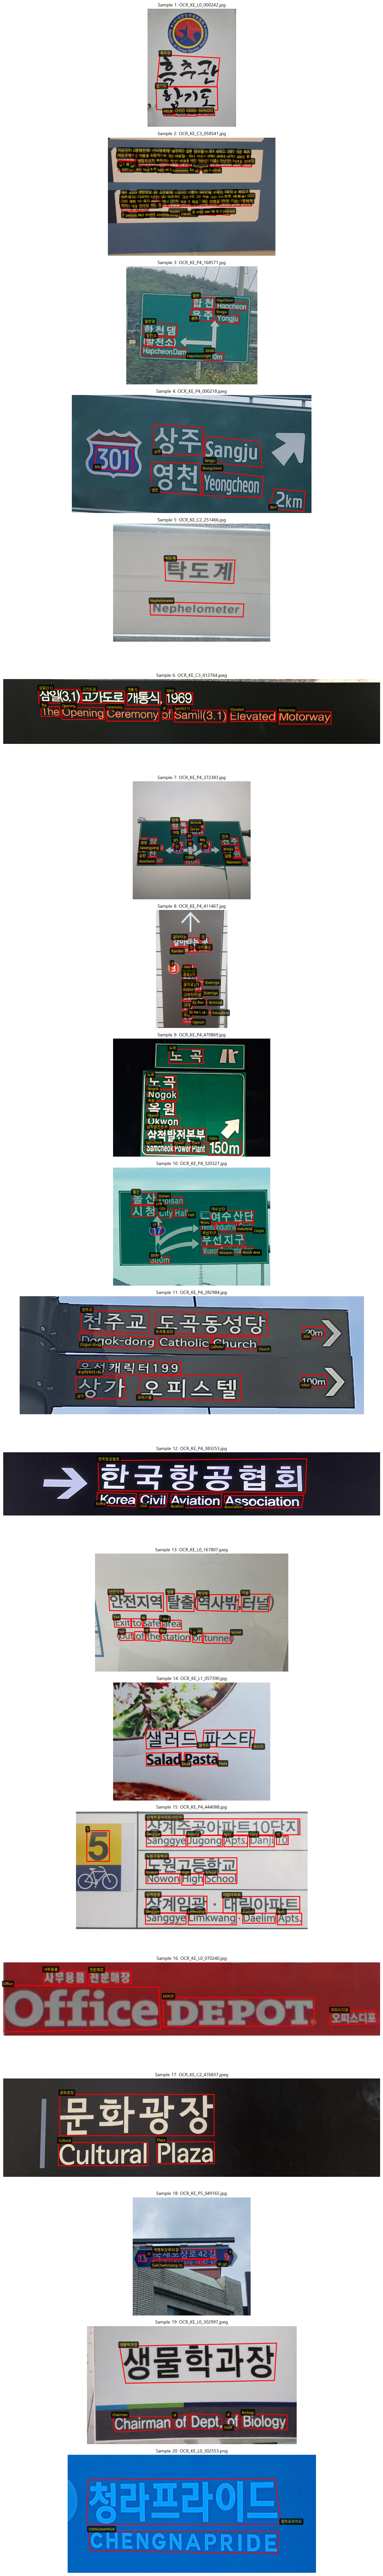


=== 검증 완료 ===
로그 파일: c:\Pyg\Projects\semi\yuzyproject-aimodels\core\paddle_train\data\logs\verify_log_20251227_170457.txt


: 

In [ ]:
# 4. 샘플 시각화 (성공한 매칭 최대 20개)
log_print("\n=== Step 4: 샘플 시각화 ===")

visualize_count = min(20, len(matched_pairs))
if visualize_count == 0:
    log_print("⚠️  시각화할 샘플이 없습니다.")
else:
    log_print(f"시각화할 샘플: {visualize_count}개")
    
    fig, axes = plt.subplots(visualize_count, 1, figsize=(12, 4 * visualize_count))
    if visualize_count == 1:
        axes = [axes]
    
    for idx, (json_file, image_path, anns) in enumerate(matched_pairs[:visualize_count]):
        img = safe_imread(image_path)
        if img is None:
            axes[idx].text(0.5, 0.5, f"Failed to load: {image_path.name}", ha='center')
            axes[idx].axis('off')
            continue
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[idx].imshow(img_rgb)
        axes[idx].set_title(f"Sample {idx+1}: {image_path.name}", fontsize=10)
        
        # anns는 이미 파싱된 형태: [{"text": str, "polygon": [[x,y],...]}, ...]
        for ann in anns:
            polygon = ann.get("polygon", [])
            text = ann.get("text", "")
            
            if not polygon or len(polygon) < 3:
                continue
            
            # polygon은 이미 [[x,y],...] 형태
            poly_points = [(p[0], p[1]) for p in polygon]
            
            # 폴리곤 그리기
            poly = Polygon(poly_points, closed=True, fill=False, edgecolor='red', linewidth=2)
            axes[idx].add_patch(poly)
            
            # 텍스트 표시 (너무 길면 일부만)
            if text and text.strip():
                display_text = text.strip()[:30] + "..." if len(text.strip()) > 30 else text.strip()
                # 첫 번째 점 위치에 텍스트 표시
                axes[idx].text(
                    poly_points[0][0], poly_points[0][1] - 5,
                    display_text, fontsize=8, color='yellow',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7)
                )
        
        axes[idx].axis('off')
    
    plt.tight_layout()
    
    # 저장
    viz_path = OUTPUT_DIR / f"sample_visualization_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
    plt.savefig(viz_path, dpi=150, bbox_inches='tight')
    log_print(f"\n✅ 시각화 결과 저장: {viz_path}")
    
    plt.show()

log_print("\n=== 검증 완료 ===")
log_print(f"로그 파일: {LOG_FILE}")
